✅ Qiskit 環境安裝完成！開始載入 AI 4.0 歷史數據...
🚀 開始執行量子模擬...

正在模擬: 2008 - Financial Crisis ...
正在模擬: 2018 - Trade War ...
正在模擬: 2020 - COVID-19 ...
正在模擬: 2024 - AI Singularity ...

✅ 所有年份模擬完成！

📊 === 歷史張力場演化分析 ===
年份 2008: 最優勢卦象代碼 [000001] (機率: 76.2%)
年份 2018: 最優勢卦象代碼 [110010] (機率: 33.4%)
年份 2020: 最優勢卦象代碼 [101011] (機率: 68.0%)
年份 2024: 最優勢卦象代碼 [100000] (機率: 46.0%)


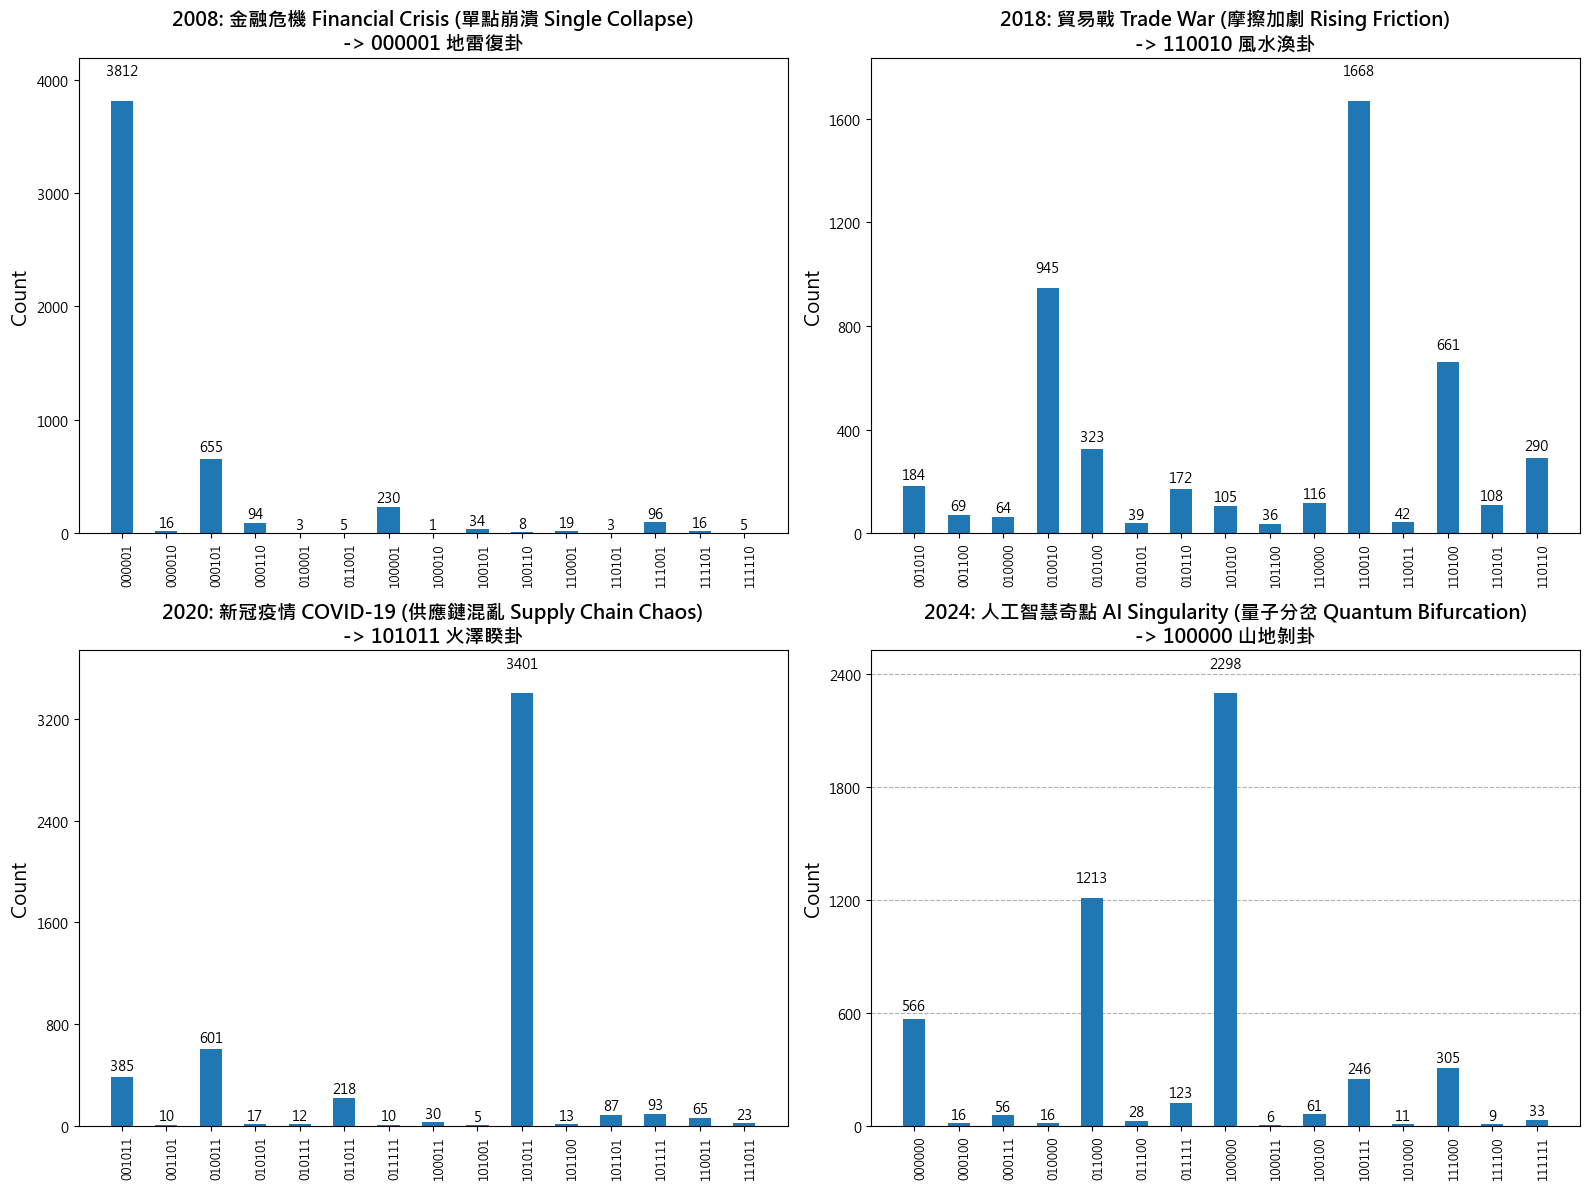

In [1]:
"""
================================================================================
【Project IQD：中美價值鏈量子糾纏與分岔 因果引擎核心代碼】
================================================================================
[1. 核心映射表 (Mapping Table)]
▶ Qubits (觀測維度): 嚴格切分為中美雙鏈 (6 Qubits)
  [美國 US Chain] 
  - q0: 國家政策 (Nation)
  - q1: 企業動能 (Corp)
  - q2: 底層供應鏈 (Supply)
  [中國 CN Chain]
  - q3: 國家政策 (Nation)
  - q4: 企業動能 (Corp)
  - q5: 底層供應鏈 (Supply)

▶ Gates (邏輯閘與事件物理意義):
  - Ry 閘 (Y-Rotation): 數據編碼器。將天地觀測值(-1.0 ~ 1.0)轉換為旋轉角，直接改變波函數振幅。
  - CNOT 閘 (CX): 垂直因果傳導。模擬國家政策(控制端)強制牽動企業與供應鏈(目標端)。
  - CZ 閘 (Phase Control): 水平地緣死鎖。中美大國(q0與q3)互不相讓的「修昔底德陷阱」相位對撞。

▶ 測量輸出 (Bitstring -> 卦象顯化):
  - 000001 (2008): 地雷復卦 (美國q0單點崩盤，因果律極度線性，帶動全球重置)
  - 110010 (2018): 風水渙卦 (完美共識產生裂痕，企業與供應鏈四處流竄，信任渙散)
  - 101011 (2020): 火澤睽卦 (二女同居其志不同行，極端壓力下中美心思背離、互相猜忌的病態共識)
  - 100000 (2024): 山地剝卦 (根基完全死寂掏空，僅剩最高國家意志對峙，經典的「量子分岔」死局)

[2. 單一案例運作流程圖 (Minimal Case Flow) - 以 2024 為例]
讀取 2024 真實數據 ──> [數值映射] q0~q5 透過 value_to_angle 將 (-1.0~1.0) 轉為角度 
                  ──> [張力注入] 對 q0~q5 施加 Ry 閘 (精準設定每個節點的初始狀態) 
                  ──> [垂直糾纏] 施加 CNOT 閘 (美: q0->q1->q2; 中: q3->q4->q5)
                  ──> [水平死鎖] 施加 CZ 閘於 q0 與 q3 (建立中美對撞張力場)
                  ──> [最終測量] 波函數顯化 (Collapse) 
                  ──> [結果輸出] 5000 次平行宇宙射擊後，統計出最高機率的主態字串
================================================================================
"""

# ==========================================================
# 步驟 0: 安裝 Qiskit 量子計算環境
# ==========================================================
# 若未安裝套件，可取消註解執行：
# !pip install qiskit qiskit-aer pylatexenc matplotlib > /dev/null
print("✅ Qiskit 環境安裝完成！開始載入 AI 4.0 歷史數據...")

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# --- [視覺化優化補丁] ---
# 確保圖表可以顯示中文，且 X 軸標籤不會重疊 (豆腐塊修復)
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'PingFang TC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
# ------------------------

# ==========================================================
# 步驟 1: 載入 Raw Data (2008-2024 天地人觀測值)
# ==========================================================
# 數值定義: -1.0 (極度收縮/崩盤/Yin) 到 +1.0 (強勢擴張/繁榮/Yang)
historical_raw_data = [
    {
        "year": 2008, "event": "Financial Crisis",
        "nodes": {
            "US_Nation": -0.8, "US_Corp": -1.0, "US_Supply": 0.5,  # 美國：崩盤帶動重組
            "CN_Nation": 0.8,  "CN_Corp": 0.9,  "CN_Supply": 0.7   # 中國：強勢擴張
        }
    },
    {
        "year": 2018, "event": "Trade War",
        "nodes": {
            "US_Nation": 0.7,  "US_Corp": -0.3, "US_Supply": -0.5, # 美國：國家強壓，企業受損
            "CN_Nation": 0.6,  "CN_Corp": -0.9, "CN_Supply": 0.2   # 中國：國家對抗，企業重傷
        }
    },
    {
        "year": 2020, "event": "COVID-19",
        "nodes": {
            "US_Nation": -0.9, "US_Corp": 0.8,  "US_Supply": -0.8, # 美國：斷鏈但數位暴漲
            "CN_Nation": -0.5, "CN_Corp": -0.7, "CN_Supply": -0.6  # 中國：全面停工
        }
    },
    {
        "year": 2024, "event": "AI Singularity",
        "nodes": {
            "US_Nation": 0.6,  "US_Corp": 1.0,  "US_Supply": 0.8,  # 美國：AI 帶動全線噴發
            "CN_Nation": 0.2,  "CN_Corp": 0.9,  "CN_Supply": -0.4  # 中國：新三樣強，晶片弱
        }
    }
]

# ==========================================================
# 步驟 2: 定義量子編碼函數與電路建構
# ==========================================================
def value_to_angle(val):
    """
    將現實觀測數值 (-1.0 ~ 1.0) 精準映射為量子旋轉角度。
    數學原理：
    - val = -1 (崩盤/收縮) -> angle = pi (推向風險態 |1>)
    - val = +1 (繁榮/擴張) -> angle = 0  (維持平穩態 |0>)
    """
    return (1 - val) * (np.pi / 2)

def build_circuit(data_node):
    qc = QuantumCircuit(6) # 6 Qubits: 0-2 (US), 3-5 (CN)

    # --- A. 編碼 (Encoding): 注入外部張力 ---
    # 直接使用 Ry 閘 (Y-Rotation)，將觀測數值轉為波函數的振幅改變
    # [US Chain 美國價值鏈]
    qc.ry(value_to_angle(data_node["US_Nation"]), 0)
    qc.ry(value_to_angle(data_node["US_Corp"]), 1)
    qc.ry(value_to_angle(data_node["US_Supply"]), 2)
    # [CN Chain 中國價值鏈]
    qc.ry(value_to_angle(data_node["CN_Nation"]), 3)
    qc.ry(value_to_angle(data_node["CN_Corp"]), 4)
    qc.ry(value_to_angle(data_node["CN_Supply"]), 5)

    # --- B. 垂直糾纏 (Vertical Entanglement): 內部因果連動 ---
    # 模擬國家政策由上而下，強制牽動企業與底層供應商的骨牌效應
    # [US 內部傳導]
    qc.cx(0, 1) # Nation -> Corp
    qc.cx(1, 2) # Corp -> Supply
    # [CN 內部傳導]
    qc.cx(3, 4) # Nation -> Corp
    qc.cx(4, 5) # Corp -> Supply

    # --- C. 水平糾纏 (Horizontal Entanglement): 地緣政治張力 ---
    # 使用 CZ Gate (相位控制閘) 模擬中美大國博弈。
    # 這是一種完美對稱的物理死鎖，當雙方皆處於高壓時，波函數相位反轉，呈現互斥對撞。
    qc.cz(0, 3) # US Nation <-> CN Nation Tension

    # --- D. 最終觀測 (Measurement) ---
    qc.measure_all()
    return qc

# ==========================================================
# 步驟 3: 執行歷史回測 (Batch Processing)
# ==========================================================
simulator = AerSimulator()
results_history = {}

print("🚀 開始執行量子模擬...\n")

# 針對 4 個歷史年代進行平行宇宙射擊
for data in historical_raw_data:
    year = data["year"]
    event = data["event"]
    print(f"正在模擬: {year} - {event} ...")

    qc = build_circuit(data["nodes"])
    compiled_circuit = transpile(qc, simulator)
    job = simulator.run(compiled_circuit, shots=5000) # 超級電腦觀測 5000 次
    result = job.result()
    counts = result.get_counts(qc)
    results_history[year] = counts

print("\n✅ 所有年份模擬完成！")

# ==========================================================
# 步驟 4: 視覺化結果 (2008 ~ 2024 歷史張力場演化矩陣)
# ==========================================================
def get_top_hexagram(counts):
    # 找出波函數顯化後，機率最高的主態卦象字串
    sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    return sorted_counts[0]

print("\n📊 === 歷史張力場演化分析 ===")
for year, counts in results_history.items():
    top_hex, count = get_top_hexagram(counts)
    prob = (count / 5000) * 100
    print(f"年份 {year}: 最優勢卦象代碼 [{top_hex}] (機率: {prob:.1f}%)")

# 繪製 2x2 演化矩陣圖 (包含 2008, 2018, 2020, 2024)
fig, axes = plt.subplots(2, 2, figsize=(16, 12)) 

# 定義四個年份的繪圖資訊 (年份, 標題, 對應的畫布位置)
plot_info = [
    (2008, "2008: 金融危機 Financial Crisis (單點崩潰 Single Collapse)\n-> 000001 地雷復卦", axes[0, 0]),
    (2018, "2018: 貿易戰 Trade War (摩擦加劇 Rising Friction)\n-> 110010 風水渙卦", axes[0, 1]),
    (2020, "2020: 新冠疫情 COVID-19 (供應鏈混亂 Supply Chain Chaos)\n-> 101011 火澤睽卦", axes[1, 0]),
    (2024, "2024: 人工智慧奇點 AI Singularity (量子分岔 Quantum Bifurcation)\n-> 100000 山地剝卦", axes[1, 1])
]

for year, title, ax in plot_info:
    # 🟢 降噪處理：過濾低機率量子雜訊，只取前 15 大機率的主態卦象
    top_counts = dict(sorted(results_history[year].items(), key=lambda item: item[1], reverse=True)[:15])
    
    # 繪製直方圖 (機率代表顯化後的命運共識強度)
    plot_histogram(top_counts, ax=ax)
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    # 🟢 視覺優化：X 軸標籤旋轉 90 度，避免二進位字串重疊
    ax.tick_params(axis='x', labelrotation=90, labelsize=9)

# 自動調整子圖之間的間距並顯示
plt.tight_layout()
plt.show()